# Ratings across run conditions

Six conditions — `(agent, prompt)` — judged by the two supervised LLM judges. Only
Claude Code and Codex at the full prompt have human ratings; the other four
(minimal prompt, and the two Terminus harnesses) have none.

No truth column, so nothing here is an accuracy. The judges' precision against
the human evaluator is 0.24–0.31, so every condition's level is depressed by roughly
the same unknown amount: read differences between conditions, not levels. Rater
throughout is `combined` — a mistake only where both judges call one.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%load_ext autoreload
%autoreload 2

# Same house style as ratings_analysis.ipynb.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 100
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

from ratings import (add_combined, agreement, conditions, drop_efficiency,
                     display, load_condition_ratings, plots)
from ratings import experiments
from ratings.experiments import (CONDITION_COLOR, CONDITION_LABEL,
                                 CONDITION_ORDER)

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

In [2]:
# Read the supervised judge verdicts straight out of
# data-format-experiments/<task>/<agent>/<timestamp>_trial<N>/verifier/judge/,
# mapping each judge's own question numbering onto our references by content.
# On the two conditions `load_ratings()` also covers, this reproduces it cell for
# cell — `python3 -m ratings validate-conditions` is that check.
r = load_condition_ratings()

# Code Efficiency questions are performance advice rather than a check on
# whether the conversion is right, and are dropped exactly as next door.
# `combined` is the two judges' consensus.
process_only = add_combined(drop_efficiency(r.tidy))
scores = conditions.condition_scores(process_only, rater="combined")

print(r)
print(f"{len(r.tidy)} rows total, {len(process_only)} after dropping "
      f"{sorted(set(r.tidy.category) - set(process_only.category))} = "
      f"{process_only.drop_duplicates(['dataset', 'qid']).shape[0]} questions"
      f" x {len(r.conditions)} conditions x 3 trials")
print("skipped:", r.skipped)

ConditionRatings(8 datasets, 6 conditions, 4284 rows, claude=4284, codex=4284)
4284 rows total, 3708 after dropping ['Code Efficiency'] = 206 questions x 6 conditions x 3 trials
skipped: {'agents': [], 'trials': ['zhang2025/codex/trial4']}


## 1. Across-judge consistency

Do the two judges still agree on the conditions nobody checked them against?

In [3]:
by_condition = agreement.pairwise(process_only, pairs=[("claude", "codex")], by="condition")
by_condition["condition"] = by_condition["condition"].map(CONDITION_LABEL)
display.agreement(by_condition)

condition,Rater A,Rater B,Pearson r,Cohen's κ
Claude Code (maximal),Claude,Codex,0.731,0.601
Claude Code (minimal),Claude,Codex,0.705,0.547
Codex (maximal),Claude,Codex,0.570,0.420
Codex (minimal),Claude,Codex,0.652,0.523
Terminus/GPT (maximal),Claude,Codex,0.701,0.583
Terminus/Opus (maximal),Claude,Codex,0.707,0.580


## 2. The harness

All four ran the full prompt, so the prompt qualifier is dropped from the
labels. Taken in pairs that share a model family, the comparison is the
scaffold alone:

| | agent harness | Terminus harness |
|---|---|---|
| Claude | Claude Code | Terminus/Opus |
| GPT | Codex | Terminus/GPT |

One point per trial; the bar is that condition's mean within the dataset.
Under the Overall boxes, mean ± SE over every point in the panel, so the ±
collapses trial and dataset noise together.

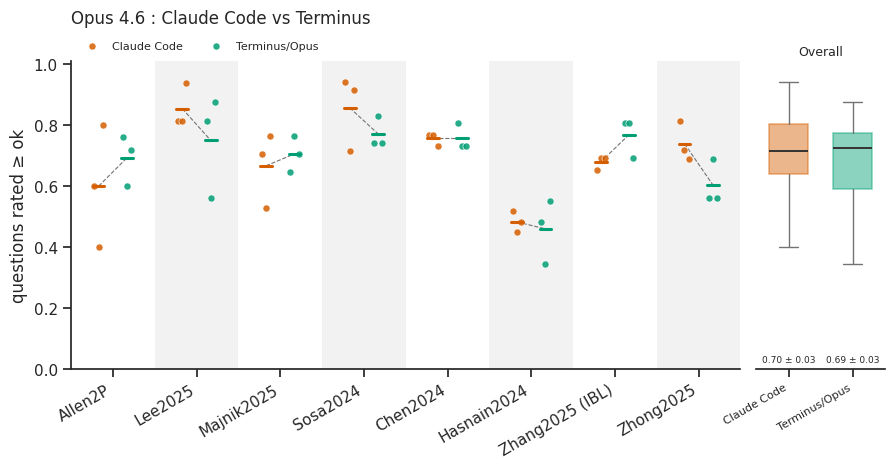

In [4]:
CLAUDE_PAIR = ("claude-code/full", "terminus-opus/full")
fig, _ = conditions.condition_scatter(scores, conditions=CLAUDE_PAIR, ylim=(0.0, 1.01),
                          title="Opus 4.6 : Claude Code vs Terminus")
plt.show()

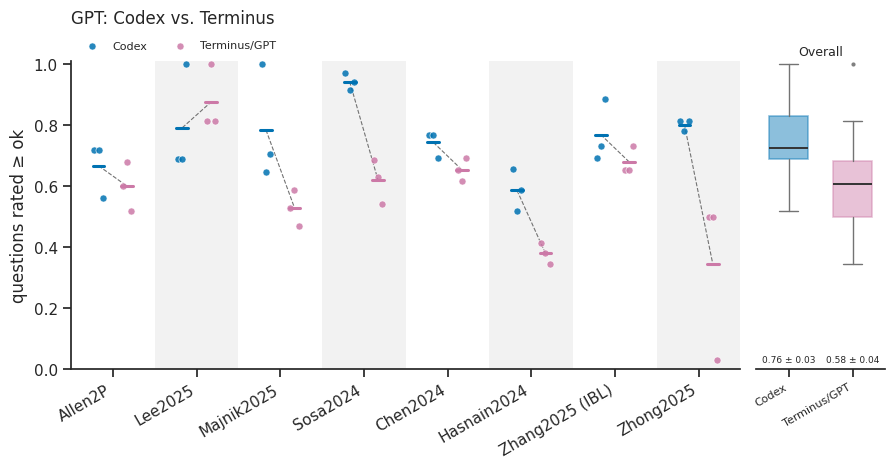

In [5]:
GPT_PAIR = ("codex/full", "terminus-gpt/full")
fig, _ = conditions.condition_scatter(scores, conditions=GPT_PAIR, ylim=(0.0, 1.01),
                          title="GPT: Codex vs. Terminus")
plt.show()

## 3. The prompt

Claude Code and Codex are the only agents that ran both, so this is paired
within-agent.

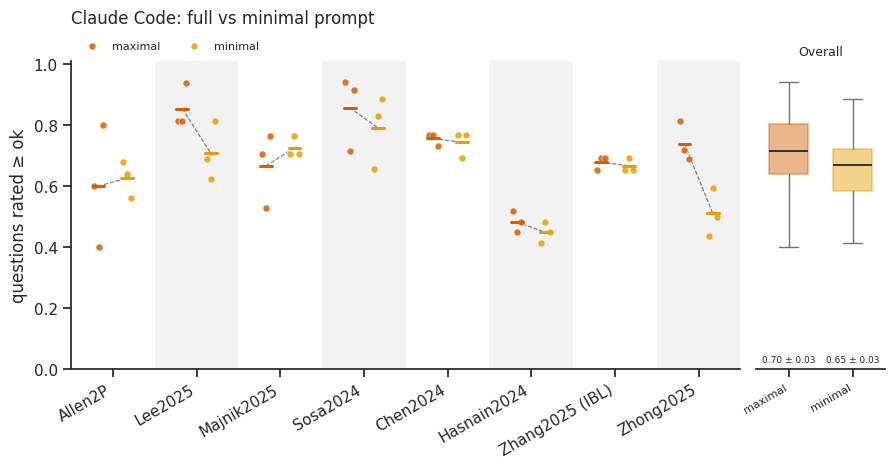

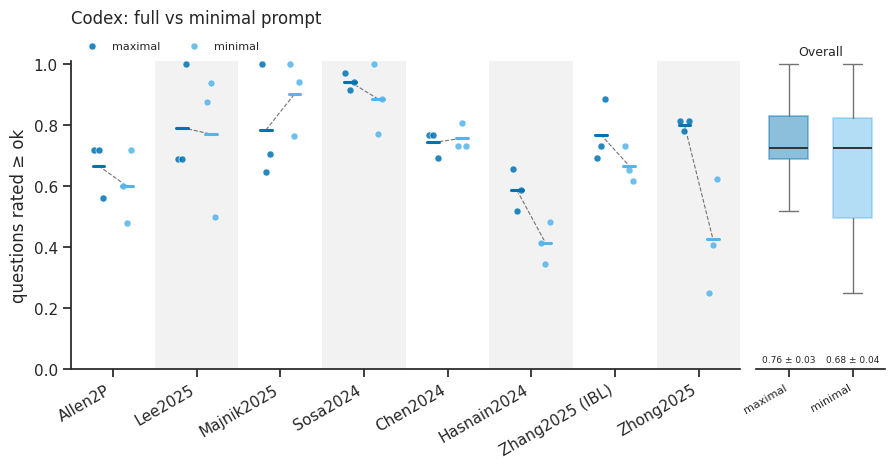

In [6]:
for agent in ("claude-code", "codex"):
    pair = (f"{agent}/full", f"{agent}/minimal")
    fig, _ = conditions.condition_scatter(
        scores, conditions=pair, ylim=(0.0, 1.01),
        title=f"{experiments.AGENT_LABEL[agent]}: full vs minimal prompt")
    plt.show()

## 4. Ratings earned

The distribution behind section 2's and 3's single numbers: the `ok`, `match`
and `better` bars are exactly the `frac_ok` numerator plotted above. Same four
comparisons, same colors.

`combined` is the element-wise max of the two judges, so the two ends of the
axis are not symmetric: `incorrect` means **both** judges said incorrect, while
`better` means **either** did. That is the rule the rest of the notebook uses at
the ok/concerning boundary, but it does inflate `better` (82 here against 46 and
37 for the two judges separately).

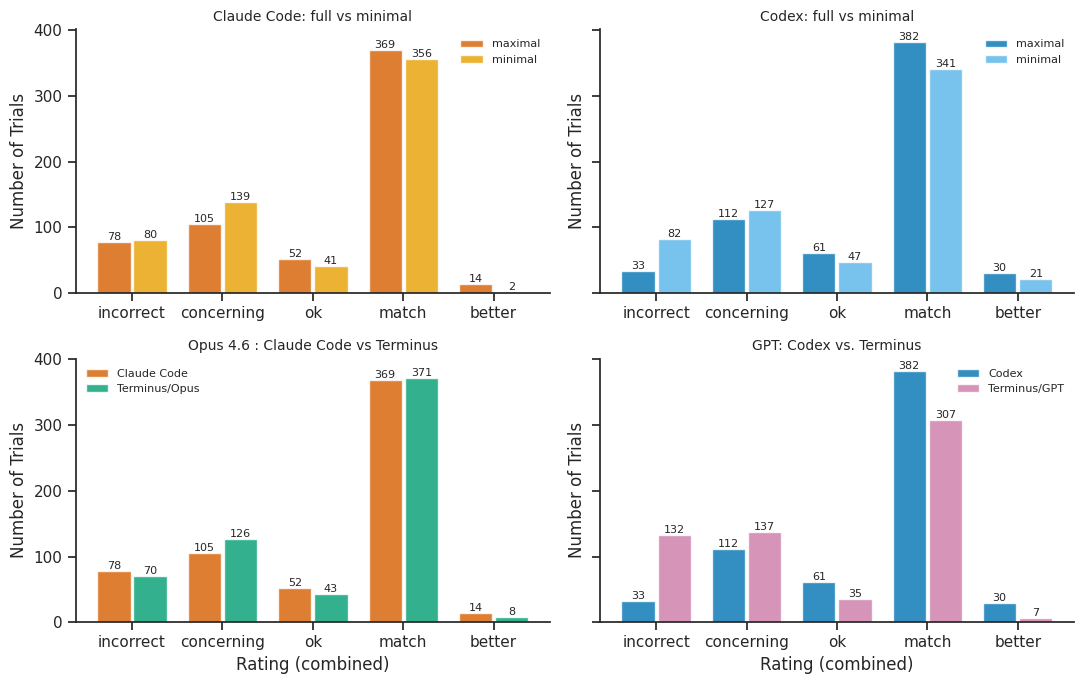

In [7]:
# The same four pairings as above — six conditions in one panel was too many to
# read, and each of these is a comparison we actually make.
COMPARISONS = [
    ("Claude Code: full vs minimal", ("claude-code/full", "claude-code/minimal")),
    ("Codex: full vs minimal",       ("codex/full", "codex/minimal")),
    ("Opus 4.6 : Claude Code vs Terminus", CLAUDE_PAIR),
    ("GPT: Codex vs. Terminus",           GPT_PAIR),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for ax, (title, pair) in zip(axes.ravel(), COMPARISONS):
    plots.rating_levels(process_only, rater="combined", ax=ax, group="condition",
                        order=pair, labels=conditions.condition_labels(pair),
                        colors=CONDITION_COLOR)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, frameon=False)
for ax in axes[0]:            # x label only under the bottom row
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

## 5. Where does each condition lose?

The same figure with question bands on the x axis instead of datasets — the
bands the summary visualization uses: Data Loading and Neural Data whole, and
Data Variables split into what the question asks about.

One point is **one dataset**, its three trials pooled: trials repeat within a
dataset, so they average, while the eight datasets are the independent samples
of a condition's score in that band.

Missing-Data Handling (8 questions) and Thresholding (2, sosa2024 only) are left
out as too thin to read; the five bands cover 196 of the 206 questions.

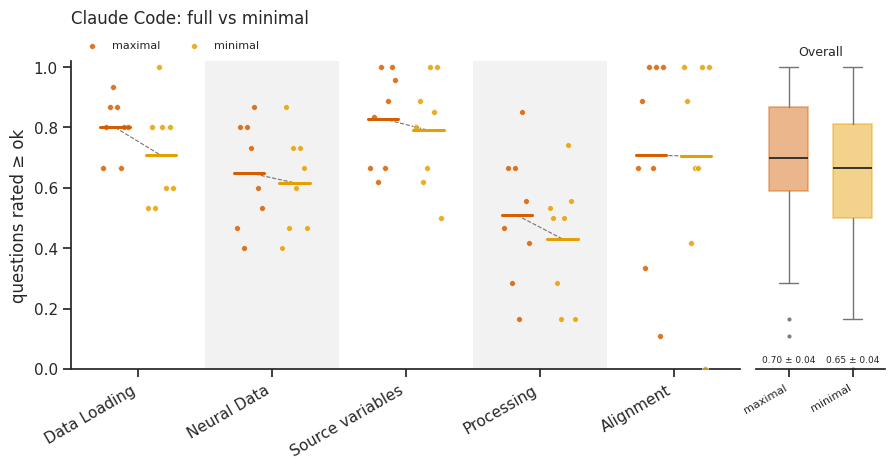

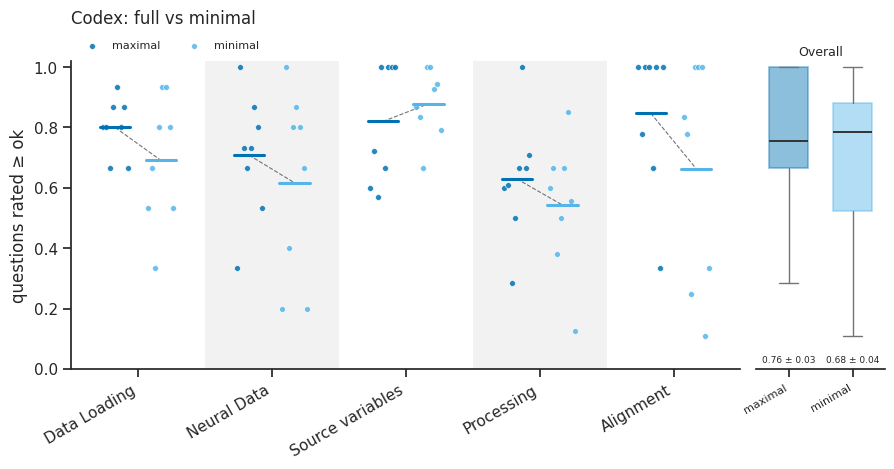

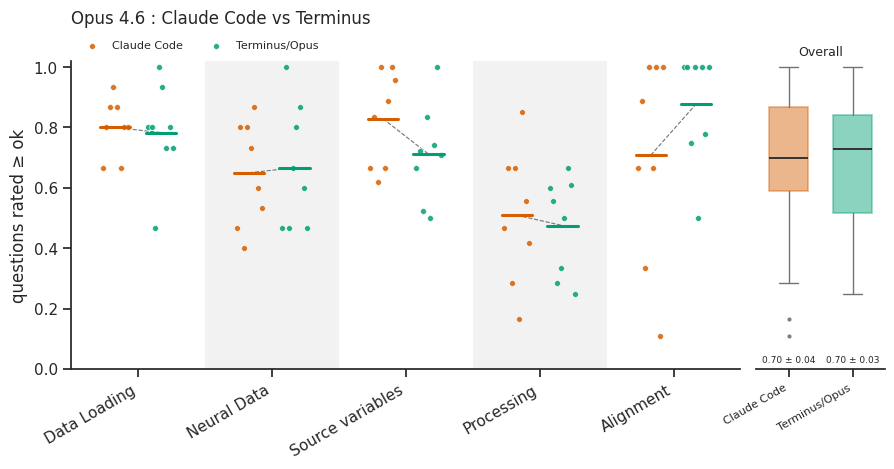

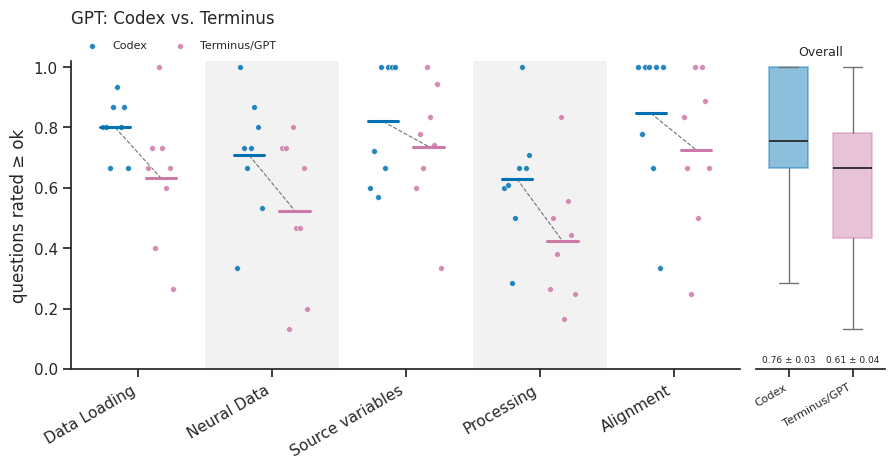

In [8]:
by_group = process_only.assign(group=conditions.question_group(process_only))
by_group = by_group[by_group.group.isin(conditions.QUESTION_GROUPS)]
group_scores = conditions.condition_scores(by_group, rater="combined",
                                           by="group", unit="dataset")

for title, pair in COMPARISONS:
    fig, _ = conditions.condition_scatter(
        group_scores, conditions=pair, x="group",
        order=list(conditions.QUESTION_GROUPS), title=title)
    plt.show()